"""
====================================================================
  Twitter Sentiment Analysis — Hate Speech Detection
  Platform : Analytics Vidhya — codefest_linguipedia
  Task     : Binary classification (0 = normal, 1 = racist/sexist)
  Metric   : F1-Score (on the minority class — hate speech)
====================================================================
How to run
----------
  pip install -r requirements.txt
  python solution.py

Outputs (saved to outputs/)
----------------------------
  test_predictions.csv      <- submit this file
  eda_overview.png          <- label distribution, tweet length, hashtags
  wordcloud_normal.png      <- word cloud for normal tweets
  wordcloud_hate.png        <- word cloud for hate speech tweets
  cv_comparison.png         <- F1 comparison across models
  confusion_matrices.png    <- confusion matrix for each model
  roc_curves.png            <- ROC + AUC for each model
  top_features.png          <- most influential TF-IDF tokens
  threshold_vs_f1.png       <- optimal classification threshold search
====================================================================
"""
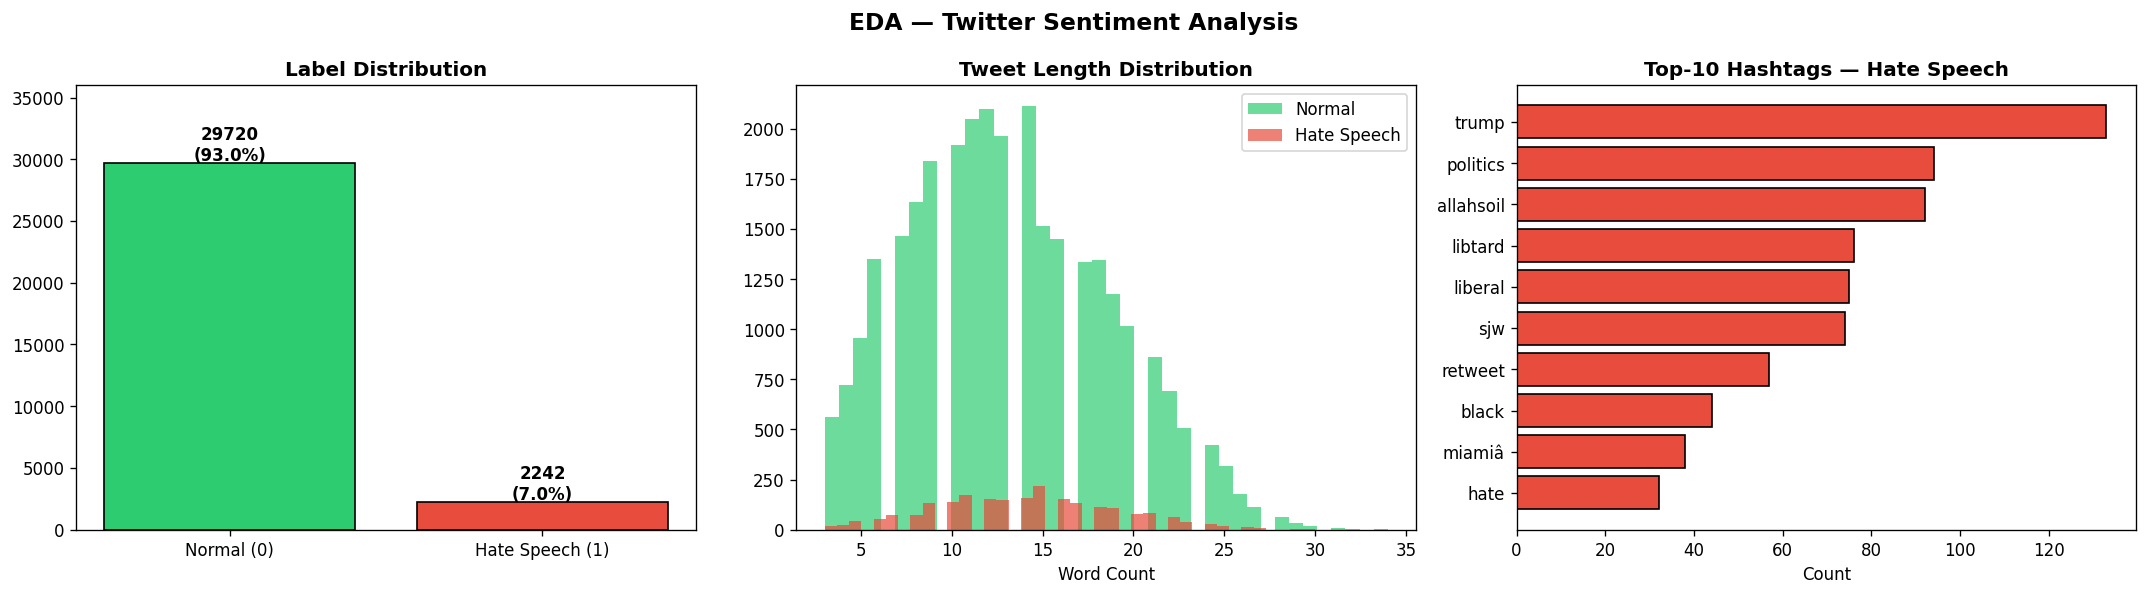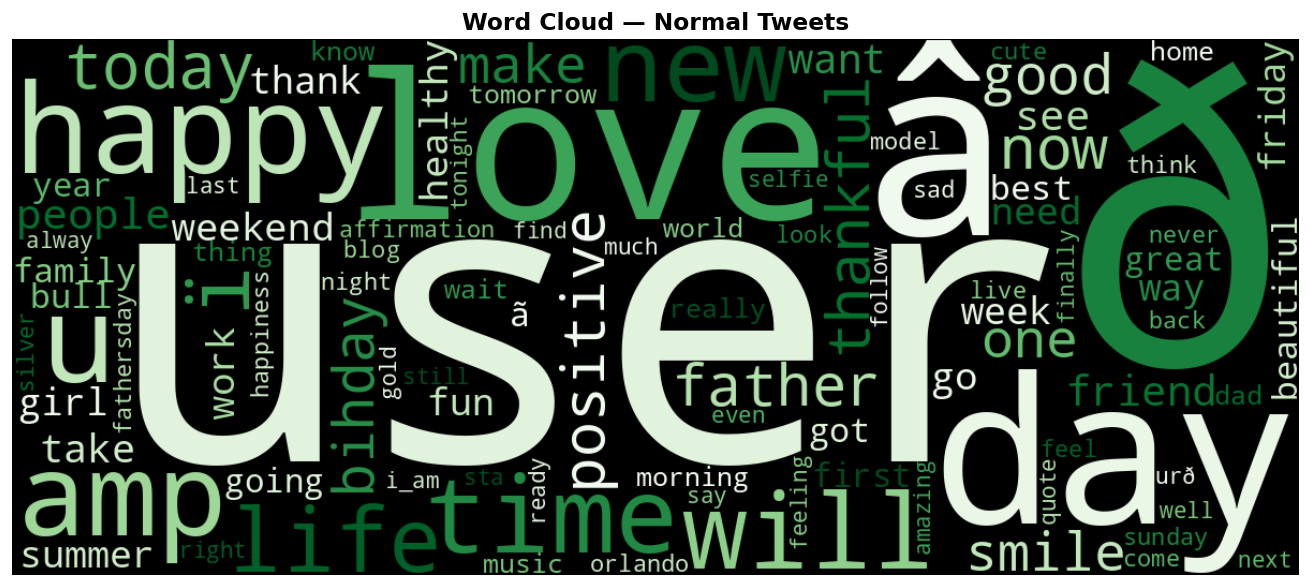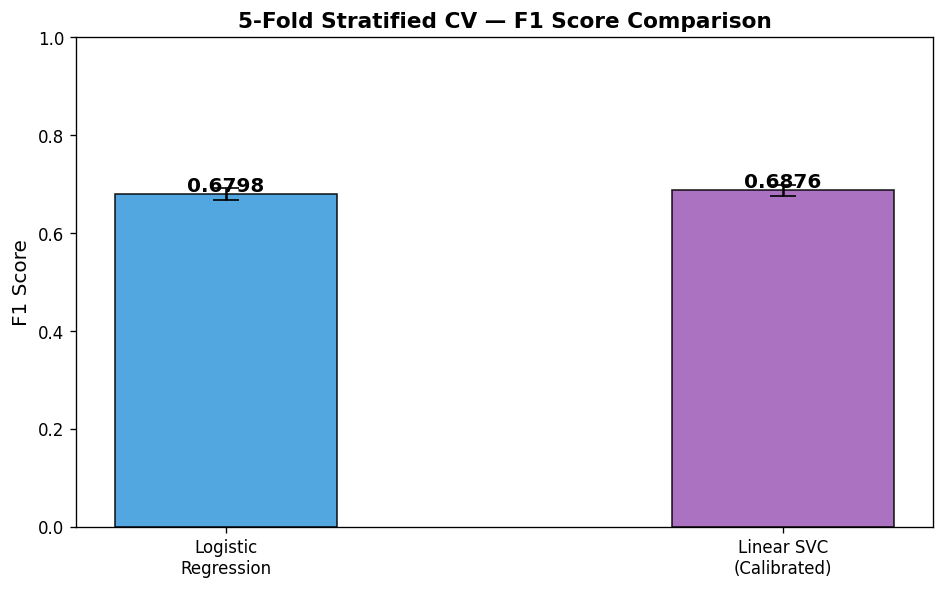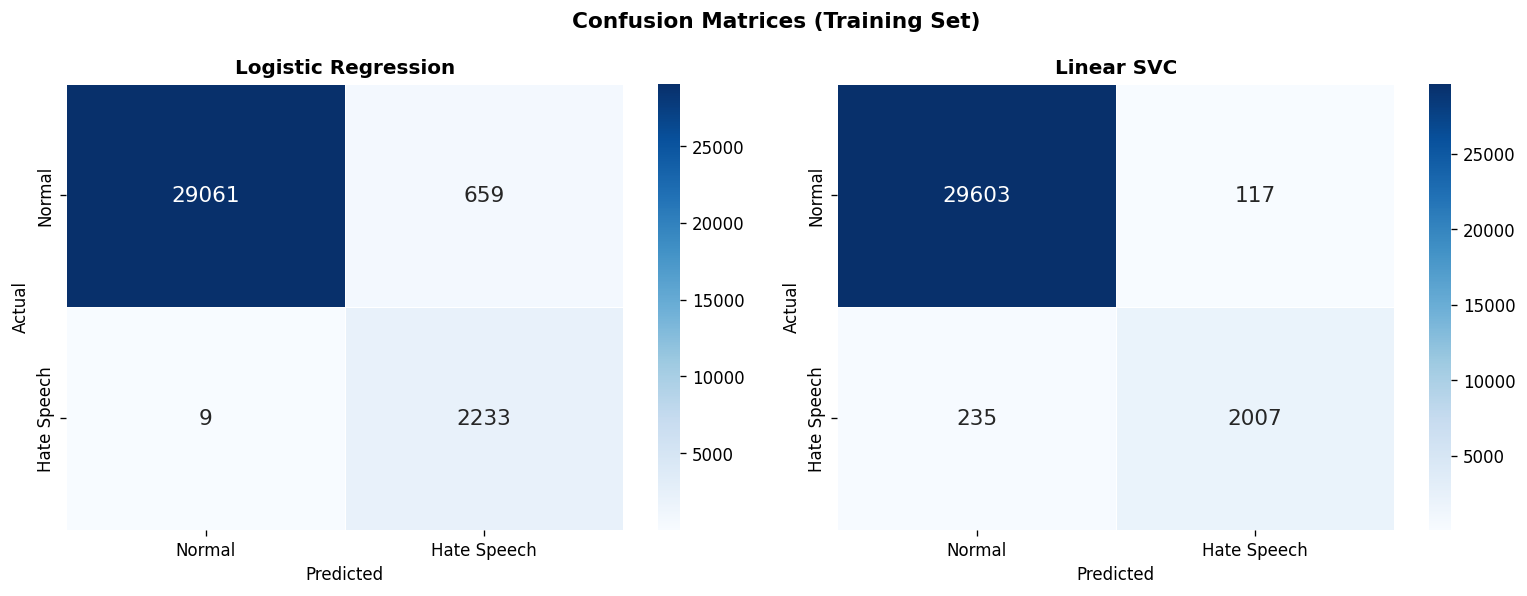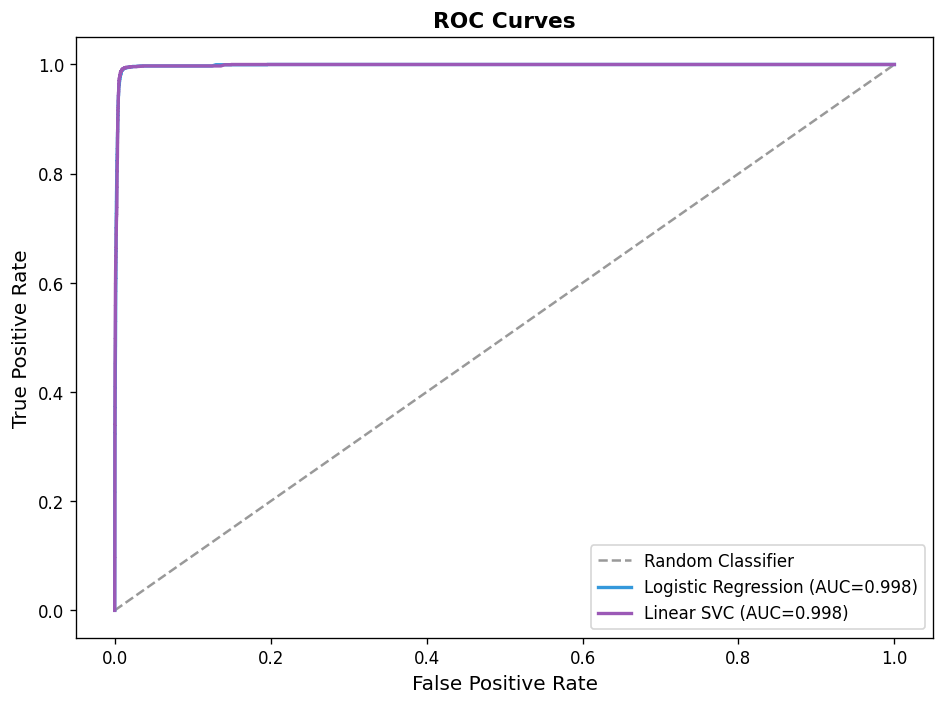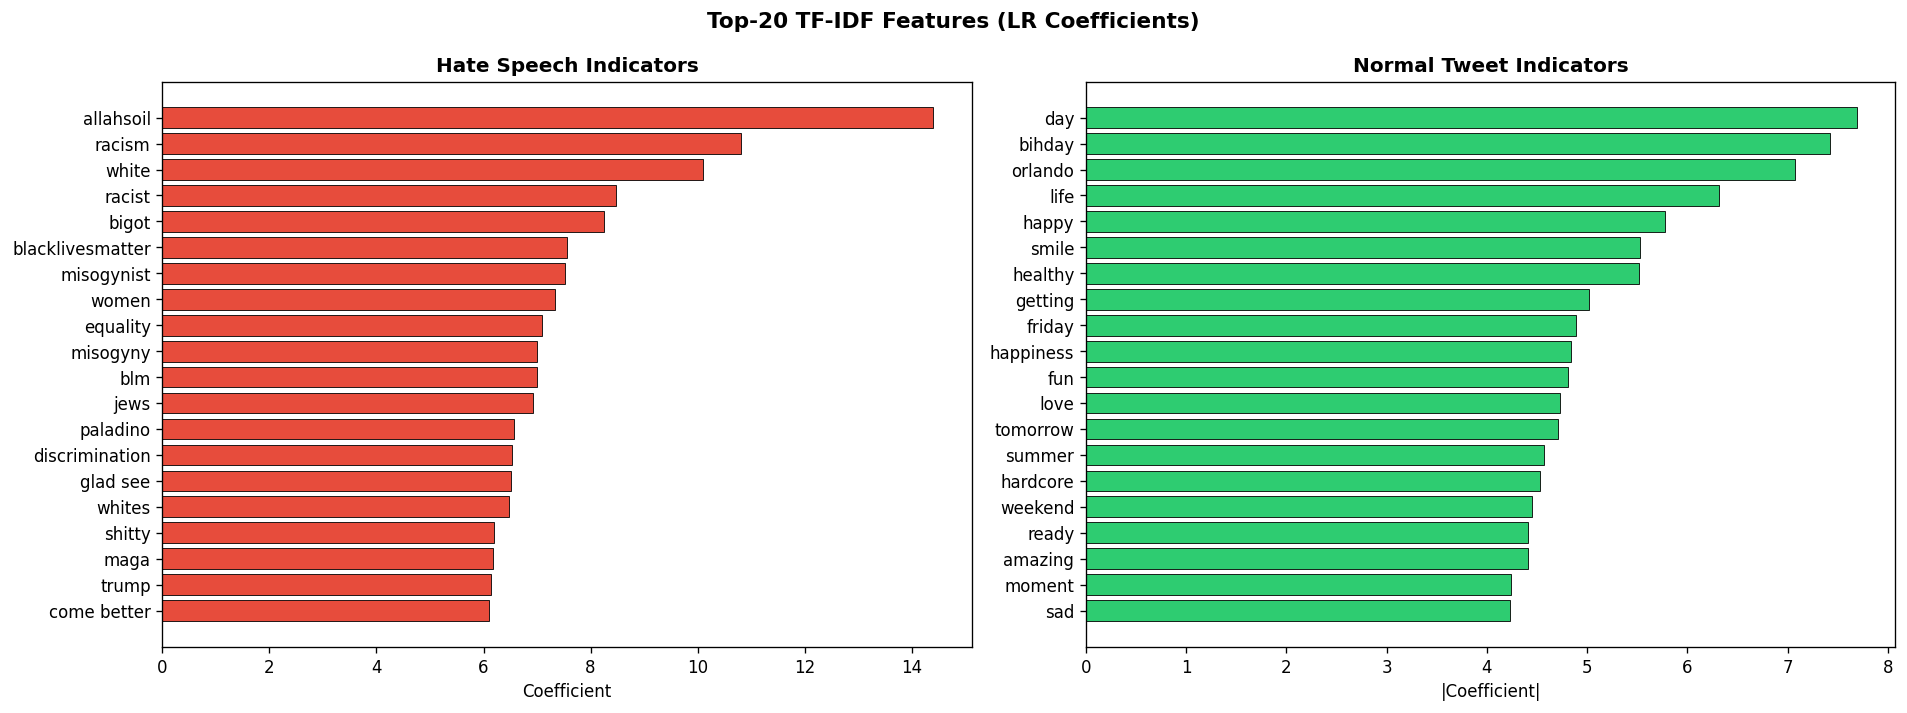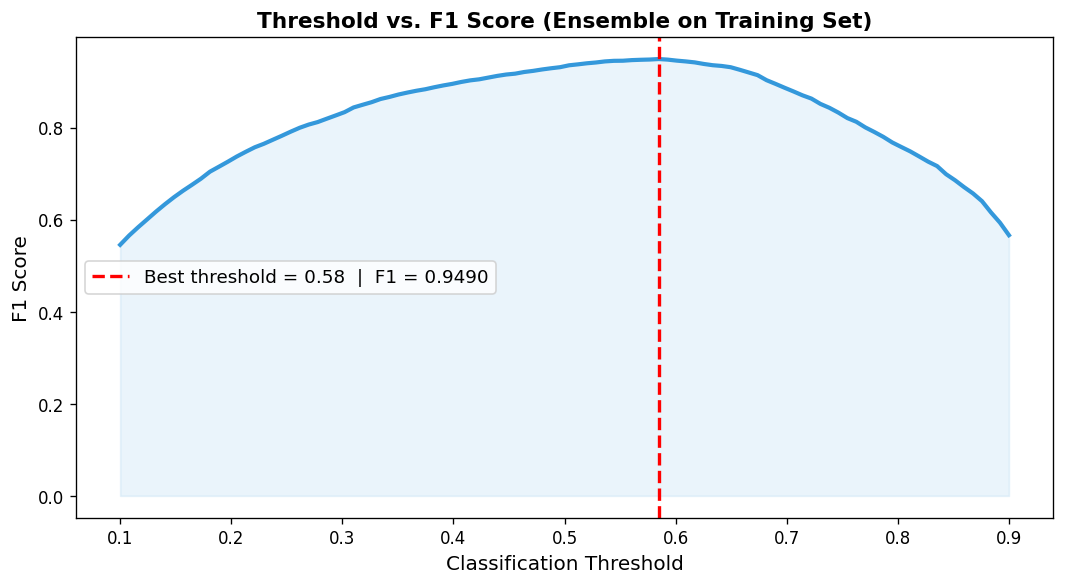



In [1]:
import os
import re
import warnings
import pickle

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")          # non-interactive backend — safe on all OS
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score, classification_report,
    confusion_matrix, roc_curve, auc,
)

warnings.filterwarnings("ignore")
np.random.seed(42)

In [2]:
# 0.  Configuration
TRAIN_PATH = "train_E6oV3lV.csv"
TEST_PATH  = "test_tweets_anuFYb8.csv"
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
# Hand-crafted stopword list (avoids external NLTK download)
STOPWORDS = {
    "i","me","my","myself","we","our","ours","ourselves","you","your","yours",
    "yourself","yourselves","he","him","his","himself","she","her","hers",
    "herself","it","its","itself","they","them","their","theirs","themselves",
    "what","which","who","whom","this","that","these","those","am","is","are",
    "was","were","be","been","being","have","has","had","having","do","does",
    "did","doing","a","an","the","and","but","if","or","because","as","until",
    "while","of","at","by","for","with","about","against","between","into",
    "through","during","before","after","above","below","to","from","up",
    "down","in","out","on","off","over","under","again","further","then",
    "once","here","there","when","where","why","how","all","both","each",
    "few","more","most","other","some","such","no","nor","not","only","own",
    "same","so","than","too","very","s","t","can","will","just","don",
    "should","now","d","ll","m","o","re","ve","y","ain","aren","couldn",
    "didn","doesn","hadn","hasn","haven","isn","ma","mightn","mustn",
    "needn","shan","shouldn","wasn","weren","won","wouldn","rt","via","amp",
}

In [4]:
# 1.  Load Data
print("=" * 62)
print("STEP 1 — Loading Data")
print("=" * 62)

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

print(f"Train shape : {train.shape}")
print(f"Test  shape : {test.shape}")
print(f"\nLabel distribution:\n{train['label'].value_counts()}")
imbalance = train["label"].value_counts()[0] / train["label"].value_counts()[1]
print(f"\nClass imbalance ratio : {imbalance:.1f}:1  (why we use class_weight='balanced')")

STEP 1 — Loading Data
Train shape : (31962, 3)
Test  shape : (17197, 2)

Label distribution:
label
0    29720
1     2242
Name: count, dtype: int64

Class imbalance ratio : 13.3:1  (why we use class_weight='balanced')


In [5]:
# 2.  Exploratory Data Analysis
print("\n" + "=" * 62)
print("STEP 2 — Exploratory Data Analysis")
print("=" * 62)

# --- 2a. Label distribution + tweet length + top hashtags ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("EDA — Twitter Sentiment Analysis", fontsize=14, fontweight="bold")

counts = train["label"].value_counts()
bars = axes[0].bar(
    ["Normal (0)", "Hate Speech (1)"], counts.values,
    color=["#2ecc71", "#e74c3c"], edgecolor="black"
)
for bar, val in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
        f"{val}\n({val/len(train)*100:.1f}%)",
        ha="center", fontsize=10, fontweight="bold"
    )
axes[0].set_title("Label Distribution", fontweight="bold")
axes[0].set_ylim(0, 36000)
axes[0].set_ylabel("Number of Tweets")

train["tweet_len"] = train["tweet"].str.split().str.len()
axes[1].hist(train[train.label == 0]["tweet_len"], bins=40,
             alpha=0.7, color="#2ecc71", label="Normal")
axes[1].hist(train[train.label == 1]["tweet_len"], bins=40,
             alpha=0.7, color="#e74c3c", label="Hate Speech")
axes[1].set_title("Tweet Length Distribution", fontweight="bold")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].legend()

def extract_hashtags(tweets):
    tags = []
    for t in tweets:
        tags.extend(re.findall(r"#(\w+)", str(t).lower()))
    return tags

hate_tags = Counter(extract_hashtags(train[train.label == 1]["tweet"])).most_common(10)
if hate_tags:
    tags, freqs = zip(*hate_tags)
    axes[2].barh(list(reversed(tags)), list(reversed(freqs)),
                 color="#e74c3c", edgecolor="black")
    axes[2].set_title("Top-10 Hashtags — Hate Speech", fontweight="bold")
    axes[2].set_xlabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_overview.png"), dpi=120, bbox_inches="tight")
plt.close()
print(f"[Saved] {OUTPUT_DIR}/eda_overview.png")


STEP 2 — Exploratory Data Analysis
[Saved] outputs/eda_overview.png


In [6]:
# --- 2b. Word clouds ---
def make_wordcloud(series, title, filename, colormap):
    text = " ".join(series.astype(str))
    wc = WordCloud(
        width=1200, height=500, background_color="black",
        colormap=colormap, max_words=100, collocations=False,
    ).generate(text)
    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=14, fontweight="bold", pad=10)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=120, bbox_inches="tight")
    plt.close()

make_wordcloud(train[train.label == 0]["tweet"],
               "Word Cloud — Normal Tweets",     "wordcloud_normal.png", "Greens")
make_wordcloud(train[train.label == 1]["tweet"],
               "Word Cloud — Hate Speech Tweets","wordcloud_hate.png",   "Reds")
print(f"[Saved] {OUTPUT_DIR}/wordcloud_normal.png")
print(f"[Saved] {OUTPUT_DIR}/wordcloud_hate.png")

[Saved] outputs/wordcloud_normal.png
[Saved] outputs/wordcloud_hate.png


In [7]:
# 3.  Text Preprocessing
print("\n" + "=" * 62)
print("STEP 3 — Text Preprocessing")
print("=" * 62)

def clean_tweet(text):
    """
    Preprocessing pipeline (applied to every tweet):
      1.  Remove @user mentions
      2.  Remove URLs
      3.  Lowercase
      4.  Keep only letters and spaces (strip punctuation, numbers)
      5.  Tokenise on whitespace
      6.  Remove stopwords and very short tokens (len <= 2)
    """
    text = str(text)
    text = re.sub(r"@\w+", "", text)              # remove @mentions
    text = re.sub(r"http\S+|www\S+", "", text)    # remove URLs
    text = text.lower()                            # lowercase
    text = re.sub(r"[^a-z\s]", " ", text)         # keep only letters
    tokens = [t for t in text.split()
              if t not in STOPWORDS and len(t) > 2]
    return " ".join(tokens)

train["clean"] = train["tweet"].apply(clean_tweet)
test["clean"]  = test["tweet"].apply(clean_tweet)

print("Sample cleaning:")
print(f"  Original : {train['tweet'].iloc[5]}")
print(f"  Cleaned  : {train['clean'].iloc[5]}")


STEP 3 — Text Preprocessing
Sample cleaning:
  Original : [2/2] huge fan fare and big talking before they leave. chaos and pay disputes when they get there. #allshowandnogo  
  Cleaned  : huge fan fare big talking leave chaos pay disputes get allshowandnogo


In [8]:
# 4.  Feature Extraction — TF-IDF (unigrams + bigrams)
print("\n" + "=" * 62)
print("STEP 4 — TF-IDF Feature Extraction")
print("=" * 62)

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),    # unigrams AND bigrams
    max_features=50_000,   # vocabulary ceiling
    min_df=3,              # ignore tokens appearing in < 3 docs
    max_df=0.90,           # ignore tokens appearing in > 90% of docs
    sublinear_tf=True,     # replace tf with 1+log(tf) — reduces skew
)

X_train = tfidf.fit_transform(train["clean"])
X_test  = tfidf.transform(test["clean"])
y_train = train["label"]

print(f"TF-IDF feature matrix : {X_train.shape}")


STEP 4 — TF-IDF Feature Extraction
TF-IDF feature matrix : (31962, 15996)


In [9]:
# 5.  Model Training — 5-Fold Stratified Cross-Validation
print("\n" + "=" * 62)
print("STEP 5 — Model Training (5-Fold Stratified CV)")
print("=" * 62)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression — fast, interpretable, strong baseline
lr = LogisticRegression(
    C=5,
    max_iter=1000,
    class_weight="balanced",   # adjusts weights inversely to class frequency
    solver="lbfgs",
    random_state=42,
)
lr_scores = cross_val_score(lr, X_train, y_train, cv=skf, scoring="f1")
print(f"Logistic Regression — CV F1: {lr_scores.mean():.4f} +/- {lr_scores.std():.4f}")

# Linear SVC — often best for high-dimensional text; wrapped for probability output
svc = CalibratedClassifierCV(
    LinearSVC(C=0.5, max_iter=2000, class_weight="balanced", random_state=42),
    cv=3,
)
svc_scores = cross_val_score(svc, X_train, y_train, cv=skf, scoring="f1")
print(f"Linear SVC (calib.) — CV F1: {svc_scores.mean():.4f} +/- {svc_scores.std():.4f}")

# CV bar chart
fig, ax = plt.subplots(figsize=(8, 5))
means  = [lr_scores.mean(), svc_scores.mean()]
stds   = [lr_scores.std(),  svc_scores.std()]
labels = ["Logistic\nRegression", "Linear SVC\n(Calibrated)"]
colors = ["#3498db", "#9b59b6"]
bars = ax.bar(labels, means, yerr=stds, capsize=8,
              color=colors, edgecolor="black", alpha=0.85, width=0.4)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.4f}", ha="center", fontsize=12, fontweight="bold")
ax.set_ylim(0, 1)
ax.set_ylabel("F1 Score", fontsize=12)
ax.set_title("5-Fold Stratified CV — F1 Score Comparison",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cv_comparison.png"), dpi=120, bbox_inches="tight")
plt.close()
print(f"[Saved] {OUTPUT_DIR}/cv_comparison.png")


STEP 5 — Model Training (5-Fold Stratified CV)
Logistic Regression — CV F1: 0.6798 +/- 0.0127
Linear SVC (calib.) — CV F1: 0.6876 +/- 0.0114
[Saved] outputs/cv_comparison.png


In [10]:
# 6.  Fit Final Models on Full Training Data
print("\n" + "=" * 62)
print("STEP 6 — Fitting Final Models")
print("=" * 62)

lr.fit(X_train, y_train)
svc.fit(X_train, y_train)
print("Models trained on full training set.")


STEP 6 — Fitting Final Models
Models trained on full training set.


In [11]:
# 7.  Evaluation — Confusion Matrix + Classification Report
print("\n" + "=" * 62)
print("STEP 7 — Evaluation (Training Set)")
print("=" * 62)

y_pred_lr  = lr.predict(X_train)
y_pred_svc = svc.predict(X_train)

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Confusion Matrices (Training Set)", fontsize=13, fontweight="bold")
for ax, name, pred in zip(axes,
                           ["Logistic Regression", "Linear SVC"],
                           [y_pred_lr, y_pred_svc]):
    cm = confusion_matrix(y_train, pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["Normal", "Hate Speech"],
        yticklabels=["Normal", "Hate Speech"],
        linewidths=0.5, annot_kws={"size": 13},
    )
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrices.png"),
            dpi=120, bbox_inches="tight")
plt.close()
print(f"[Saved] {OUTPUT_DIR}/confusion_matrices.png")

print("\n--- Classification Report (Logistic Regression) ---")
print(classification_report(y_train, y_pred_lr,
                             target_names=["Normal (0)", "Hate Speech (1)"]))

# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random Classifier")
for model, name, color in [
    (lr,  "Logistic Regression", "#3498db"),
    (svc, "Linear SVC",          "#9b59b6"),
]:
    prob = model.predict_proba(X_train)[:, 1]
    fpr, tpr, _ = roc_curve(y_train, prob)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{name} (AUC = {auc(fpr, tpr):.3f})")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "roc_curves.png"), dpi=120, bbox_inches="tight")
plt.close()
print(f"[Saved] {OUTPUT_DIR}/roc_curves.png")

# Top TF-IDF features
feature_names = tfidf.get_feature_names_out()
coef = lr.coef_[0]
top_hate   = np.argsort(coef)[-20:][::-1]
top_normal = np.argsort(coef)[:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Top-20 TF-IDF Features (LR Coefficients)",
             fontsize=13, fontweight="bold")
axes[0].barh([feature_names[i] for i in reversed(top_hate)],
             [coef[i] for i in reversed(top_hate)],
             color="#e74c3c", edgecolor="black", linewidth=0.5)
axes[0].set_title("Hate Speech Indicators", fontweight="bold")
axes[0].set_xlabel("Coefficient")

axes[1].barh([feature_names[i] for i in reversed(top_normal)],
             [abs(coef[i]) for i in reversed(top_normal)],
             color="#2ecc71", edgecolor="black", linewidth=0.5)
axes[1].set_title("Normal Tweet Indicators", fontweight="bold")
axes[1].set_xlabel("|Coefficient|")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top_features.png"), dpi=120, bbox_inches="tight")
plt.close()
print(f"[Saved] {OUTPUT_DIR}/top_features.png")


STEP 7 — Evaluation (Training Set)
[Saved] outputs/confusion_matrices.png

--- Classification Report (Logistic Regression) ---
                 precision    recall  f1-score   support

     Normal (0)       1.00      0.98      0.99     29720
Hate Speech (1)       0.77      1.00      0.87      2242

       accuracy                           0.98     31962
      macro avg       0.89      0.99      0.93     31962
   weighted avg       0.98      0.98      0.98     31962

[Saved] outputs/roc_curves.png
[Saved] outputs/top_features.png


In [12]:
# 8.  Ensemble + Threshold Tuning
print("\n" + "=" * 62)
print("STEP 8 — Weighted Ensemble + Threshold Tuning")
print("=" * 62)

# Weighted average of probabilities (weights = CV F1 score)
w_lr  = lr_scores.mean()
w_svc = svc_scores.mean()
total = w_lr + w_svc

train_prob = (w_lr * lr.predict_proba(X_train)[:, 1] +
              w_svc * svc.predict_proba(X_train)[:, 1]) / total
test_prob  = (w_lr * lr.predict_proba(X_test)[:, 1] +
              w_svc * svc.predict_proba(X_test)[:, 1]) / total

# Search for threshold that maximises F1 on training set
thresholds = np.linspace(0.10, 0.90, 100)
f1_scores  = [f1_score(y_train, (train_prob >= t).astype(int))
              for t in thresholds]
best_t = thresholds[np.argmax(f1_scores)]
print(f"Best threshold : {best_t:.2f}   Train F1 : {max(f1_scores):.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, f1_scores, color="#3498db", linewidth=2.5)
ax.fill_between(thresholds, f1_scores, alpha=0.1, color="#3498db")
ax.axvline(x=best_t, color="red", linestyle="--", linewidth=2,
           label=f"Best threshold = {best_t:.2f}  |  F1 = {max(f1_scores):.4f}")
ax.set_xlabel("Classification Threshold", fontsize=12)
ax.set_ylabel("F1 Score", fontsize=12)
ax.set_title("Threshold vs. F1 Score (Ensemble)", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "threshold_vs_f1.png"),
            dpi=120, bbox_inches="tight")
plt.close()
print(f"[Saved] {OUTPUT_DIR}/threshold_vs_f1.png")


STEP 8 — Weighted Ensemble + Threshold Tuning
Best threshold : 0.58   Train F1 : 0.9490
[Saved] outputs/threshold_vs_f1.png


In [13]:
# 9.  Submission File
print("\n" + "=" * 62)
print("STEP 9 — Creating Submission File")
print("=" * 62)

final_pred = (test_prob >= best_t).astype(int)
submission = pd.DataFrame({"label": final_pred})
sub_path   = os.path.join(OUTPUT_DIR, "test_predictions.csv")
submission.to_csv(sub_path, index=False)

print(f"[Saved] {sub_path}")
print(f"Submission shape   : {submission.shape}")
print(f"Label 0 (Normal)   : {(final_pred == 0).sum()}")
print(f"Label 1 (Hate)     : {(final_pred == 1).sum()}")

print("\n" + "=" * 62)
print("ALL DONE — check the outputs/ folder")
print("=" * 62)


STEP 9 — Creating Submission File
[Saved] outputs/test_predictions.csv
Submission shape   : (17197, 1)
Label 0 (Normal)   : 16125
Label 1 (Hate)     : 1072

ALL DONE — check the outputs/ folder
